## Layered Beta P&L Attribution for Long–Short Equity Portfolios

Five-component P&L attribution for a mutual fund or ETF, following the
methodology of Chapter 1 of the accompanying report:
 
    1) SPX beta            - period-average portfolio beta x SPX return
    2) Bucket betas        - period-average incremental industry/country betas
                             x bucket-index returns orthogonalized to SPX
    3) Market timing       - incremental effect of time variation in the SPX
                             beta and in the bucket betas around their averages
    4) Stock selection     - residual security-specific contribution
    5) Residual            - holdings that cannot be bucketed or priced
                             (plus non-equity sleeves)
 
Data sources
* Holdings:  WRDS, CRSP Mutual Fund Database (ticker -> crsp_fundno ->
             crsp_portno -> portfolio holdings). Requires a WRDS account.
* Buckets:   Anthropic Claude API selects the bucketing scheme
             (industry vs. country), the buckets, a liquid index ETF per
             bucket, and assigns each holding to a bucket.
* Prices:    Free online sources via yfinance (Yahoo Finance), with the
             S&P 500 proxied by ^GSPC.

The script requires *wrds, anthropic, yfinance, pandas, numpy* and *matplotlib*, a WRDS account with CRSP MFDB access, and an *ANTHROPIC_API_KEY* environment variable.

In [1]:
import json
import os

import numpy as np
import pandas as pd

import yfinance as yf

In [2]:
%matplotlib inline

COLORS = {"SPX beta": "#2E5E8C", "Bucket betas": "#E8923A", "Market timing": "#4C9F70", "Stock selection": "#8E5DA2", "Residual": "#9AA0A6"}

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [3]:
sApiKey = os.environ["SK_ANT_API"]
sModel = "claude-sonnet-4-20250514"

import anthropic

In [4]:
sWrdsUser = "cs4143"

import wrds

In [5]:
nLookback = 24

ticker = "ARKK"
startDt = "2019-01-01"
endDt = "2026-06-12"

### Retrieve holdings from WRDS
Map the fund ticker to CRSP identifiers and pull portfolio holdings.

    CRSP MFDB chain:  fund_hdr (ticker -> crsp_fundno)
                      portnomap (crsp_fundno -> crsp_portno, with date ranges)
                      holdings  (crsp_portno + report_dt -> security positions)

Expand reported snapshots to a monthly grid: within each month the share count of every position is the one from the most recent report (constant intra-month shares, forward-filled across unreported months).

This implements the identifier chain of the CRSP Mutual Fund Database. The provided ticker is first converted into the appropriate fund ID: the cell opens a connection with *wrds.Connection(wrds_username=...)* and resolves the ticker in *crsp.fund_hdr* (falling back to the historical *crsp.fund_names* file), which yields one *crsp_fundno* per share class. Because share classes of the same fund hold one common portfolio, the script then maps every *crsp_fundno* through *crsp.portnomap* to the portfolio identifier *crsp_portno*, and finally pulls position snapshots — *report_dt, cusip, permno, ticker, nbr_shares, market_val* — from *crsp.holdings* for the requested window (extended one month back so the first month has a starting snapshot). The last cell  then expands the snapshots onto a month-end grid implementing the Chapter 1 convention: within each month, every position carries the share count from the most recent report — “the number of shares of each security remains constant intra-month” — and quarterly reporters are forward-filled across unreported months.

In [6]:
    db = wrds.Connection(wrds_username=sWrdsUser)
    fund = db.raw_sql(
        """
        SELECT crsp_fundno, fund_name, ticker
        FROM   crsp.fund_hdr
        WHERE  ticker = %(tic)s
        """, params={"tic": ticker.upper()})
    if fund.empty:
        fund = db.raw_sql(
            """
            SELECT DISTINCT crsp_fundno, fund_name, ticker
            FROM   crsp.fund_names
            WHERE  ticker = %(tic)s
            """, params={"tic": ticker.upper()})

    fund_name = fund["fund_name"].iloc[0]
    fundnos = tuple(fund["crsp_fundno"].astype(int).tolist())
    print(f"[wrds] {ticker} -> {fund_name} (crsp_fundno {fundnos})")

Loading library list...
Done
[wrds] ARKK -> ARK ETF Trust: ARK Innovation ETF (crsp_fundno (62590,))


In [7]:
    ports = db.raw_sql(
        f"""
        SELECT DISTINCT crsp_portno
        FROM   crsp.portnomap
        WHERE  crsp_fundno IN {fundnos if len(fundnos) > 1 else f'({fundnos[0]})'}
        """)
    portnos = tuple(ports["crsp_portno"].astype(int).tolist())

    holdings = db.raw_sql(
        f"""
        SELECT h.crsp_portno, h.report_dt, h.cusip, h.permno,
               h.ticker AS sec_ticker, h.security_name,
               h.nbr_shares, h.market_val, h.percent_tna
        FROM   crsp.holdings AS h
        WHERE  h.crsp_portno IN {portnos if len(portnos) > 1 else f'({portnos[0]})'}
          AND  h.report_dt BETWEEN %(d0)s AND %(d1)s
        """,
        params={"d0": (pd.Timestamp(startDt) - pd.DateOffset(months=1)).date(),
                "d1": pd.Timestamp(endDt).date()})

    holdings["report_dt"] = pd.to_datetime(holdings["report_dt"])
    print(f"[wrds] {holdings['report_dt'].nunique()} holding snapshots, {holdings['cusip'].nunique()} distinct securities")

[wrds] 87 holding snapshots, 122 distinct securities


In [8]:
    months = pd.date_range(startDt, endDt, freq="ME")
    snaps = {dt: g for dt, g in holdings.groupby("report_dt")}
    snap_dates = sorted(snaps)
    monthly = {}
    for m in months:
        prior = [d for d in snap_dates if d <= m]
        if prior:
            monthly[m] = snaps[prior[-1]][
                ["cusip", "permno", "sec_ticker", "security_name",
                 "nbr_shares", "market_val"]].copy()

### Claude determines buckets
Ask Claude to (i) decide industry vs. country bucketing, (ii) name the buckets and one liquid index ETF per bucket, and (iii) assign every underlying position to a bucket

This delegates the judgment call of Step 2 of the methodology — industry versus country bucketing, the bucket list, and a representative index per bucket — to Claude. This compiles the distinct holdings into compact *cusip|ticker|name* lines, embeds them in a prompt that states the three tasks and demands a strict JSON reply *({"scheme": ..., "buckets": [...], "assignments": {...}})*, and calls *client.messages.create(model=model, ...)*. The response text is stripped of any code fences and parsed with *json.loads*; securities the model cannot confidently place are mapped to the special bucket *Unmapped*, which routes them into component 5. Centralizing this choice in a language model gives consistent, auditable bucket definitions across hundreds of funds while keeping a human-readable record (the JSON) of every assignment.

In [9]:
    client = anthropic.Anthropic(api_key=sApiKey)
    secs = holdings[["cusip", "sec_ticker", "security_name"]].drop_duplicates("cusip").fillna("")
    sec_lines = "\n".join(f"{r.cusip}|{r.sec_ticker}|{r.security_name[:60]}" for r in secs.itertuples())

    prompt = f"""You are assisting with P&L attribution for the fund "{fund_name}".
Below is its list of equity holdings as 'cusip|ticker|name' lines.

Tasks:
1. Decide whether the fund is US-centric (bucket by INDUSTRY) or
   international (bucket by COUNTRY).
2. Define 4-8 buckets that cover the portfolio, and for each bucket choose
   one liquid, investable index ETF traded in the US (e.g. XLK, XBI, EWJ,
   MCHI) that best represents it.
3. Assign every cusip to exactly one bucket. If a security cannot be
   confidently assigned, map it to the special bucket "UNMAPPED".

Respond ONLY with JSON, no prose and no markdown fences, in the schema:
{{"scheme": "industry" or "country",
  "buckets": [{{"name": "...", "index_ticker": "..."}}, ...],
  "assignments": {{"<cusip>": "<bucket name>", ...}}}}

Holdings:
{sec_lines}"""

    msg = client.messages.create(model=sModel, max_tokens=8000, messages=[{"role": "user", "content": prompt}])

    text = "".join(b.text for b in msg.content if b.type == "text")
    text = text.strip().removeprefix("```json").removeprefix("```").removesuffix("```")
    spec = json.loads(text)

    scheme = spec["scheme"]
    bucket_index = {b["name"]: b["index_ticker"] for b in spec["buckets"]}
    cusip_bucket = spec["assignments"]
    print(f"[claude] scheme={scheme}; buckets: "
          + ", ".join(f"\n{k} ({v})" for k, v in bucket_index.items()))

[claude] scheme=industry; buckets: 
Software & Cloud (XLK), 
Biotechnology & Genomics (XBI), 
Semiconductors (SOXX), 
Internet & E-commerce (ARKW), 
Fintech & Digital Assets (FINX), 
Autonomous & Robotics (ROBO), 
Gaming & Entertainment (NERD), 
UNMAPPED (VTI)


### Download all necessary historical prices

In this script, using Yahoo Finance alone; can be expanded to support international equities

This fetches monthly adjusted closes from Yahoo Finance for every holding ticker, every bucket index ETF and the S&P 500 proxy *^GSPC*, reaching back lookback + 2 months before the start date so that the first attribution month already has a full beta window. 

In [10]:
def download_prices(tickers, start, end, lookback_months):
    """Monthly adjusted close prices from Yahoo Finance, with enough history
    before `start` to estimate the first betas."""

    hist_start = (pd.Timestamp(start) - pd.DateOffset(months=lookback_months + 2)).date()
    px = yf.download(sorted(set(tickers)), start=str(hist_start), end=end, interval="1mo", auto_adjust=True, progress=False)["Close"]
    if isinstance(px, pd.Series):
        px = px.to_frame(tickers[0])
    px.index = px.index + pd.offsets.MonthEnd(0)
    return px.sort_index()

In [12]:
    ticker_of = (holdings.dropna(subset=["sec_ticker"])
                 .drop_duplicates("cusip").set_index("cusip")["sec_ticker"]
                 .str.upper().to_dict())
    sec_tickers = sorted(set(ticker_of.values()))
    idx_tickers = sorted(set(bucket_index.values()))

    px = download_prices(sec_tickers + idx_tickers + ["^GSPC"], startDt, endDt, nLookback)
    rets = px.pct_change()
    spx_ret = rets["^GSPC"]

HTTP Error 404: 

22 Failed downloads:
['EB', 'NSTG', 'MDSO', 'SRNG', 'SPLK', 'LP4000', 'SQ', 'LP4001', 'NVTA', 'EXAS', 'TWTR', 'WORK', 'ONVO', 'BREA', 'SGFY', 'LP4009', 'DLPH', 'VERV', 'TSP', 'BLI', 'TWOU', 'XLNX']: YFTzMissingError('possibly delisted; no timezone found')
C:\Users\cyril\AppData\Local\Temp\ipykernel_24256\2435890455.py:8: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = px.pct_change()


### Calculate betas

First w.r. to SPX than w.r. to bucket indexes

*rolling_beta* computes trailing OLS betas as rolling covariance over rolling variance, which is identical to a univariate regression slope. *estimate_betas* implements the two-pass logic of our steps (1)–(3): for each security it first estimates the SPX beta, then removes the market impact *(resid = returns[sec] - b1 * spx_ret)* and regresses the residual on the bucket index’s own SPX-orthogonalized return, so that the SPX and bucket contributions are additive by construction. Securities without a priceable ticker simply never enter these frames and fall through to the residual component.

In [13]:
def rolling_beta(y, x, window):
    """Trailing OLS beta of y on x (both return Series), one value per month."""

    df = pd.concat([y, x], axis=1, keys=["y", "x"]).dropna()
    cov = df["y"].rolling(window).cov(df["x"])
    var = df["x"].rolling(window).var()
    return (cov / var).reindex(y.index)

def estimate_betas(returns, spx_ret, bucket_ret_orth, sec_bucket, window):
    """For each security: trailing SPX beta, then incremental bucket beta
    estimated on SPX-residual returns against the orthogonalized bucket
    index, so the two contributions are additive."""

    beta_spx, beta_bkt = {}, {}
    for sec in returns.columns:
        b1 = rolling_beta(returns[sec], spx_ret, window)
        beta_spx[sec] = b1
        resid = returns[sec] - b1 * spx_ret
        bkt = sec_bucket.get(sec)
        if bkt is not None and bkt in bucket_ret_orth:
            beta_bkt[sec] = rolling_beta(resid, bucket_ret_orth[bkt], window)
        else:
            beta_bkt[sec] = pd.Series(0.0, index=returns.index)
    return pd.DataFrame(beta_spx), pd.DataFrame(beta_bkt)

In [14]:
    bucket_ret_orth = {}
    for bname, itic in bucket_index.items():
        if itic not in rets.columns:
            continue
        b = rolling_beta(rets[itic], spx_ret, nLookback)
        bucket_ret_orth[bname] = (rets[itic] - b * spx_ret).dropna()

    sec_bucket = {ticker_of[c]: b for c, b in cusip_bucket.items() if c in ticker_of and b in bucket_ret_orth}
    sec_px = px[[t for t in sec_tickers if t in px.columns]]
    beta_spx, beta_bkt = estimate_betas(sec_px.pct_change(), spx_ret, bucket_ret_orth, sec_bucket, nLookback)

C:\Users\cyril\AppData\Local\Temp\ipykernel_24256\2663380443.py:10: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  beta_spx, beta_bkt = estimate_betas(sec_px.pct_change(), spx_ret, bucket_ret_orth, sec_bucket, nLookback)


### Perform attribution

Using the data prepared in the steps above.
Lastly, generate a plot

This is the core. For each month, we value the snapshot at beginning-of-month prices *(vals[r.cusip] = r.nbr_shares * prices.loc[m0, tic])*, forming weights over a NAV that includes the unpriced sleeve, whose share *w_res* is carried at reported market value. It then aggregates security betas into the portfolio-level *Bspx* and per-bucket *Bbkt*. After the monthly loop, the period-average betas *Bspx_avg* and *Bbkt_avg* are computed — these are the constant betas of components 1 and 2 — and each month’s five contributions follow the definitions of Table 1 verbatim: *c1 = Bspx_avg * r_spx; c2 = Σ Bbkt_avg[b] * x_b; c3* prices the deviations of both beta families from their averages; and *c4 = r_port_mapped - (c1 + c2 + c3)* books stock selection as the residual of the mapped portfolio, guaranteeing additivity. The unpriced sleeve’s within-month return is conservatively booked at zero, with snapshot revaluations flowing through at month ends

In [15]:
    months = sorted(monthly)
    rows = []
    rets = px.pct_change()

    for m in months:
        pos = monthly[m]
        prev = px.index[px.index < m]
        if len(prev) == 0 or m not in rets.index:
            continue
        m0 = prev[-1]

        vals, unmapped_val = {}, 0.0
        for r in pos.itertuples():
            tic = ticker_of.get(r.cusip)
            if tic in px.columns and not np.isnan(px.loc[m0, tic]):
                vals[r.cusip] = r.nbr_shares * px.loc[m0, tic]
            else:
                unmapped_val += (r.market_val if not np.isnan(r.market_val) else 0.0)
        nav = sum(vals.values()) + unmapped_val
        if nav <= 0:
            continue
        w = {c: v / nav for c, v in vals.items()}
        w_res = unmapped_val / nav

        Bspx = sum(w[c] * np.nan_to_num(beta_spx.loc[m, ticker_of[c]]) for c in w)
        Bbkt = {}
        for c in w:
            bkt = sec_bucket.get(ticker_of[c])
            if bkt in bucket_ret_orth:
                Bbkt[bkt] = Bbkt.get(bkt, 0.0) + w[c] * np.nan_to_num(beta_bkt.loc[m, ticker_of[c]])

        r_spx = spx_ret.loc[m]
        r_sec = {c: rets.loc[m, ticker_of[c]] for c in w}
        rows.append({"month": m, "w": w, "w_res": w_res, "Bspx": Bspx,
                     "Bbkt": Bbkt, "r_spx": r_spx, "r_sec": r_sec})

    Bspx_avg = np.mean([r["Bspx"] for r in rows])
    all_bkts = sorted({b for r in rows for b in r["Bbkt"]})
    Bbkt_avg = {b: np.mean([r["Bbkt"].get(b, 0.0) for r in rows]) for b in all_bkts}

    out = []
    for r in rows:
        m = r["month"]
        c1 = Bspx_avg * r["r_spx"]
        c2 = sum(Bbkt_avg[b] * bucket_ret_orth[b].get(m, 0.0) for b in all_bkts)
        c3 = (r["Bspx"] - Bspx_avg) * r["r_spx"] + sum((r["Bbkt"].get(b, 0.0) - Bbkt_avg[b])
                 * bucket_ret_orth[b].get(m, 0.0) for b in all_bkts)
        r_port_mapped = sum(r["w"][c] * np.nan_to_num(r["r_sec"][c]) for c in r["w"])
        c4 = r_port_mapped - (c1 + c2 + c3)
        c5 = 0.0 * r["w_res"]
        out.append({"date": m, "SPX beta": c1, "Bucket betas": c2,
                    "Market timing": c3, "Stock selection": c4, "Residual": c5})

    contrib = pd.DataFrame(out).set_index("date")
    print(f"[info] average SPX beta = {Bspx_avg:.2f}; "
          f"average bucket betas = { {k: round(v, 2) for k, v in Bbkt_avg.items()} }")

C:\Users\cyril\AppData\Local\Temp\ipykernel_24256\953573344.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  rets = px.pct_change()


[info] average SPX beta = 1.40; average bucket betas = {'Autonomous & Robotics': np.float64(0.08), 'Biotechnology & Genomics': np.float64(0.06), 'Fintech & Digital Assets': np.float64(0.04), 'Gaming & Entertainment': np.float64(0.01), 'Internet & E-commerce': np.float64(0.06), 'Semiconductors': np.float64(0.02), 'Software & Cloud': np.float64(0.07), 'UNMAPPED': np.float64(0.01)}


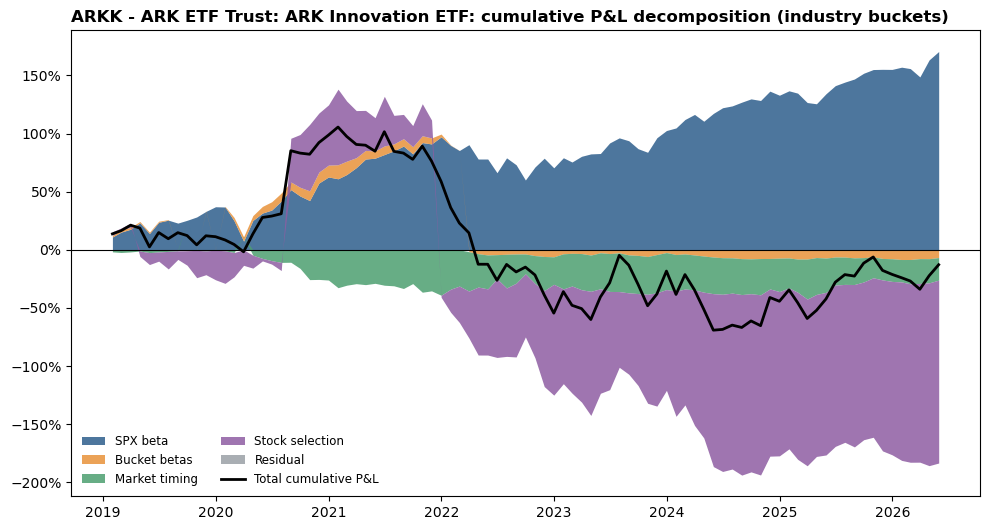

In [16]:
    title = f"{ticker.upper()} - {fund_name}: cumulative P&L decomposition ({scheme} buckets)"
    cum = contrib.cumsum()
    fig, ax = plt.subplots(figsize=(10, 5.4))
    pos = np.zeros(len(cum)); neg = np.zeros(len(cum))
    for col in cum.columns:
        v = cum[col].values
        base = np.where(v >= 0, pos, neg)
        ax.fill_between(cum.index, base, base + v, color=COLORS[col],
                        alpha=0.85, linewidth=0, label=col)
        pos += np.maximum(v, 0); neg += np.minimum(v, 0)
    ax.plot(cum.index, cum.sum(axis=1), color="black", lw=2,
            label="Total cumulative P&L")
    ax.axhline(0, color="black", lw=0.8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title(title, loc="left", fontweight="bold")
    ax.legend(loc="best", frameon=False, fontsize=8.5, ncol=2)
    fig.tight_layout()
    plt.show()

In [18]:
fig.savefig(ticker)